# Recursive Sketch hyperparameter search across OpenML-CC18

This notebook is intentionally thin: OpenML loading, candidate construction, the random-search loop, result summaries, and visualizations live in `openml_hyperparameter_search.py`. Configure the experiment below, run the search, and then render the reports.

In [6]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import sys
from pathlib import Path

import pandas as pd

notebooks_dir = Path.cwd() / 'notebooks'
if not (notebooks_dir / 'openml_hyperparameter_search.py').exists():
    notebooks_dir = Path.cwd()
if str(notebooks_dir) not in sys.path:
    sys.path.insert(0, str(notebooks_dir))

from openml_hyperparameter_search import (
    best_configuration,
    best_scores_by_dataset,
    plot_marginalized_performance,
    plot_pairwise_performance,
    plot_top_candidates,
    run_search,
)

In [2]:
# Edit this cell to configure the OpenML search.
DATASET_SEED = 4279
SEARCH_SEED = 177
DATASET_NAMES = None

SMOKE_TEST = True
DATASET_COUNT = 5 if SMOKE_TEST else 8
MAX_DATASET_SIZE = 400 if SMOKE_TEST else 1000
REPETITIONS = tuple(range(5)) if SMOKE_TEST else tuple(range(10))
N_SEARCH_ITER = 20 if SMOKE_TEST else 100
TEST_SIZE = 0.30
N_JOBS = -1
OUTPUT_CLASSIFIER_N_ESTIMATORS = 100

# RecursiveSketch parameters plus model choices; each list is its range.
PARAMETER_RANGES = {
    'n_estimators': [30, 100, 300],
    'n_iterations': [1, 2, 3, 4],
    'dimension_mode': ['fixed', 'expanding'],
    'normalization': ['none', 'l1', 'l2'],
    'dimension_ratio': [1, 10, 20, 30, 40],
    'initial_projection_type': ['sparse', 'gaussian', 'signed_hash'],
    'path_projection_type': ['sparse', 'gaussian', 'signed_hash'],
    'concat_projection_type': ['sparse', 'gaussian', 'signed_hash'],
    'classifier': ['logistic_regression', 'random_forest', 'svm_rbf_auto_lambda'],
    'path_estimator': ['random_forest', 'recursive_partition'],
}

In [3]:
search_outputs = run_search(
    dataset_names=DATASET_NAMES,
    dataset_count=DATASET_COUNT,
    max_dataset_size=MAX_DATASET_SIZE,
    dataset_seed=DATASET_SEED,
    repetitions=REPETITIONS,
    parameter_ranges=PARAMETER_RANGES,
    n_search_iter=N_SEARCH_ITER,
    search_seed=SEARCH_SEED,
    test_size=TEST_SIZE,
    n_jobs=N_JOBS,
    output_classifier_n_estimators=OUTPUT_CLASSIFIER_N_ESTIMATORS,
)
datasets = search_outputs['datasets']
dataset_summary = search_outputs['dataset_summary']
evaluation_blocks = search_outputs['evaluation_blocks']
sampled_parameters = search_outputs['sampled_parameters']
search_results = search_outputs['search_results']
block_results = search_outputs['block_results']

display(dataset_summary)
display(pd.DataFrame(sampled_parameters))
display(search_results)

Random-search candidates  0%|          | 0/20 [00:00<?, ?it/s]

Candidate  0%|          | 0/25 [00:00<?, ?it/s]

/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/s

Candidate  0%|          | 0/25 [00:00<?, ?it/s]

/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/sklearn/svm/_base.py:755: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/sklearn/svm/_base.py:755: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/sklearn/svm/_base.py:755: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/sklearn/svm/_base.py:755: UserWarning: The number of unique classes is greater than 50% of the number of samples

...

Candidate  0%|          | 0/25 [00:00<?, ?it/s]

/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/sklearn/svm/_base.py:755: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/sklearn/svm/_base.py:755: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/sklearn/svm/_base.py:755: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/sklearn/svm/_base.py:755: UserWarning: The number of unique classes is greater than 50% of the number of samples

,dataset_id,name,n_original,n_used,n_features
0,3,kr-vs-kp,3196,400,36
1,6,letter,20000,400,16
2,11,balance-scale,625,400,4
3,12,mfeat-factors,2000,400,216
4,14,mfeat-fourier,2000,400,76


,path_projection_type,path_estimator,normalization,n_iterations,n_estimators,initial_projection_type,dimension_ratio,dimension_mode,concat_projection_type,classifier
0,gaussian,random_forest,l1,2,300,gaussian,40,fixed,signed_hash,random_forest
1,signed_hash,recursive_partition,l1,3,300,sparse,30,fixed,signed_hash,logistic_regression
2,sparse,random_forest,none,3,30,signed_hash,20,expanding,gaussian,random_forest
3,gaussian,recursive_partition,l2,4,300,gaussian,20,expanding,signed_hash,svm_rbf_auto_lambda
4,gaussian,random_forest,l1,3,300,gaussian,1,expanding,signed_hash,logistic_regression
5,gaussian,recursive_partition,none,1,300,signed_hash,30,expanding,signed_hash,logistic_regression
6,signed_hash,recursive_partition,l2,4,100,signed_hash,30,expanding,gaussian,random_forest
7,signed_hash,recursive_partition,l1,4,30,sparse,20,fixed,sparse,logistic_regression
8,sparse,random_forest,l1,1,100,signed_hash,30,expanding,signed_hash,random_forest
9,sparse,random_forest,l2,2,30,sparse,30,expanding,sparse,random_forest


,candidate_id,path_projection_type,path_estimator,normalization,n_iterations,n_estimators,initial_projection_type,dimension_ratio,dimension_mode,concat_projection_type,classifier,mean_accuracy,std_dataset_accuracy,mean_block_accuracy,search_seconds
0,5,gaussian,recursive_partition,none,1,300,signed_hash,30,expanding,signed_hash,logistic_regression,0.865000,0.114109,0.865000,186.072667
1,16,signed_hash,recursive_partition,none,4,30,gaussian,40,expanding,signed_hash,svm_rbf_auto_lambda,0.851000,0.108785,0.851000,576.769921
2,11,gaussian,recursive_partition,none,4,30,sparse,10,fixed,signed_hash,random_forest,0.850000,0.121769,0.850000,142.875297
3,12,signed_hash,random_forest,l1,3,30,sparse,40,expanding,sparse,logistic_regression,0.837000,0.158252,0.837000,222.607206
4,15,sparse,recursive_partition,l1,3,300,gaussian,20,expanding,gaussian,logistic_regression,0.828000,0.137161,0.828000,9779.163814
5,1,signed_hash,recursive_partition,l1,3,300,sparse,30,fixed,signed_hash,logistic_regression,0.819667,0.160197,0.819667,3450.255406
6,9,sparse,random_forest,l2,2,30,sparse,30,expanding,sparse,random_forest,0.806333,0.164542,0.806333,36.980514
7,0,gaussian,random_forest,l1,2,300,gaussian,40,fixed,signed_hash,random_forest,0.802333,0.172858,0.802333,307.482646
8,3,gaussian,recursive_partition,l2,4,300,gaussian,20,expanding,signed_hash,svm_rbf_auto_lambda,0.794667,0.179959,0.794667,5368.069067
9,6,signed_hash,recursive_partition,l2,4,100,signed_hash,30,expanding,gaussian,random_forest,0.793667,0.183403,0.793667,1909.530665


,candidate_id,path_projection_type,path_estimator,normalization,n_iterations,n_estimators,initial_projection_type,dimension_ratio,dimension_mode,concat_projection_type,classifier,mean_accuracy,std_dataset_accuracy,mean_block_accuracy,search_seconds
0,5,gaussian,recursive_partition,none,1,300,signed_hash,30,expanding,signed_hash,logistic_regression,0.865,0.114,0.865,186.1
1,16,signed_hash,recursive_partition,none,4,30,gaussian,40,expanding,signed_hash,svm_rbf_auto_lambda,0.851,0.109,0.851,576.8
2,11,gaussian,recursive_partition,none,4,30,sparse,10,fixed,signed_hash,random_forest,0.850,0.122,0.850,142.9
3,12,signed_hash,random_forest,l1,3,30,sparse,40,expanding,sparse,logistic_regression,0.837,0.158,0.837,222.6
4,15,sparse,recursive_partition,l1,3,300,gaussian,20,expanding,gaussian,logistic_regression,0.828,0.137,0.828,9779.2
5,1,signed_hash,recursive_partition,l1,3,300,sparse,30,fixed,signed_hash,logistic_regression,0.820,0.160,0.820,3450.3
6,9,sparse,random_forest,l2,2,30,sparse,30,expanding,sparse,random_forest,0.806,0.165,0.806,37.0
7,0,gaussian,random_forest,l1,2,300,gaussian,40,fixed,signed_hash,random_forest,0.802,0.173,0.802,307.5
8,3,gaussian,recursive_partition,l2,4,300,gaussian,20,expanding,signed_hash,svm_rbf_auto_lambda,0.795,0.180,0.795,5368.1
9,6,signed_hash,recursive_partition,l2,4,100,signed_hash,30,expanding,gaussian,random_forest,0.794,0.183,0.794,1909.5


,n_estimators,n_iterations,dimension_mode,normalization,dimension_ratio,initial_projection_type,path_projection_type,concat_projection_type,classifier,path_estimator
0,300,1,expanding,none,30,signed_hash,gaussian,signed_hash,logistic_regression,recursive_partition


,dataset_id,dataset,mean_accuracy,std_accuracy,n_repetitions
0,3,kr-vs-kp,0.952,0.015,5
3,12,mfeat-factors,0.947,0.017,5
2,11,balance-scale,0.925,0.024,5
4,14,mfeat-fourier,0.815,0.027,5
1,6,letter,0.687,0.034,5


,parameter,value,n_candidates,q25_accuracy,median_accuracy,q75_accuracy
0,n_estimators,30,8,0.741,0.790,0.840
1,n_estimators,100,5,0.676,0.761,0.775
2,n_estimators,300,7,0.765,0.802,0.824
3,n_iterations,1,3,0.718,0.761,0.813
4,n_iterations,2,4,0.764,0.788,0.803
5,n_iterations,3,6,0.735,0.782,0.826
6,n_iterations,4,7,0.754,0.794,0.822
7,dimension_mode,fixed,8,0.687,0.753,0.807
8,dimension_mode,expanding,12,0.757,0.794,0.830
9,normalization,none,5,0.773,0.850,0.851


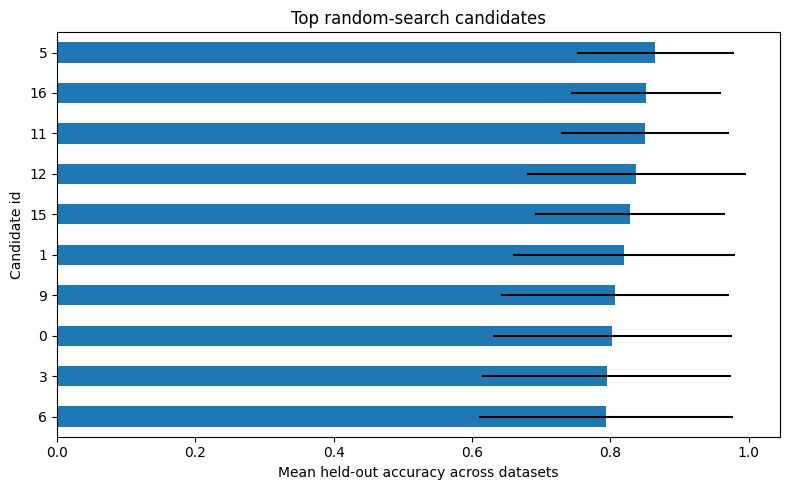

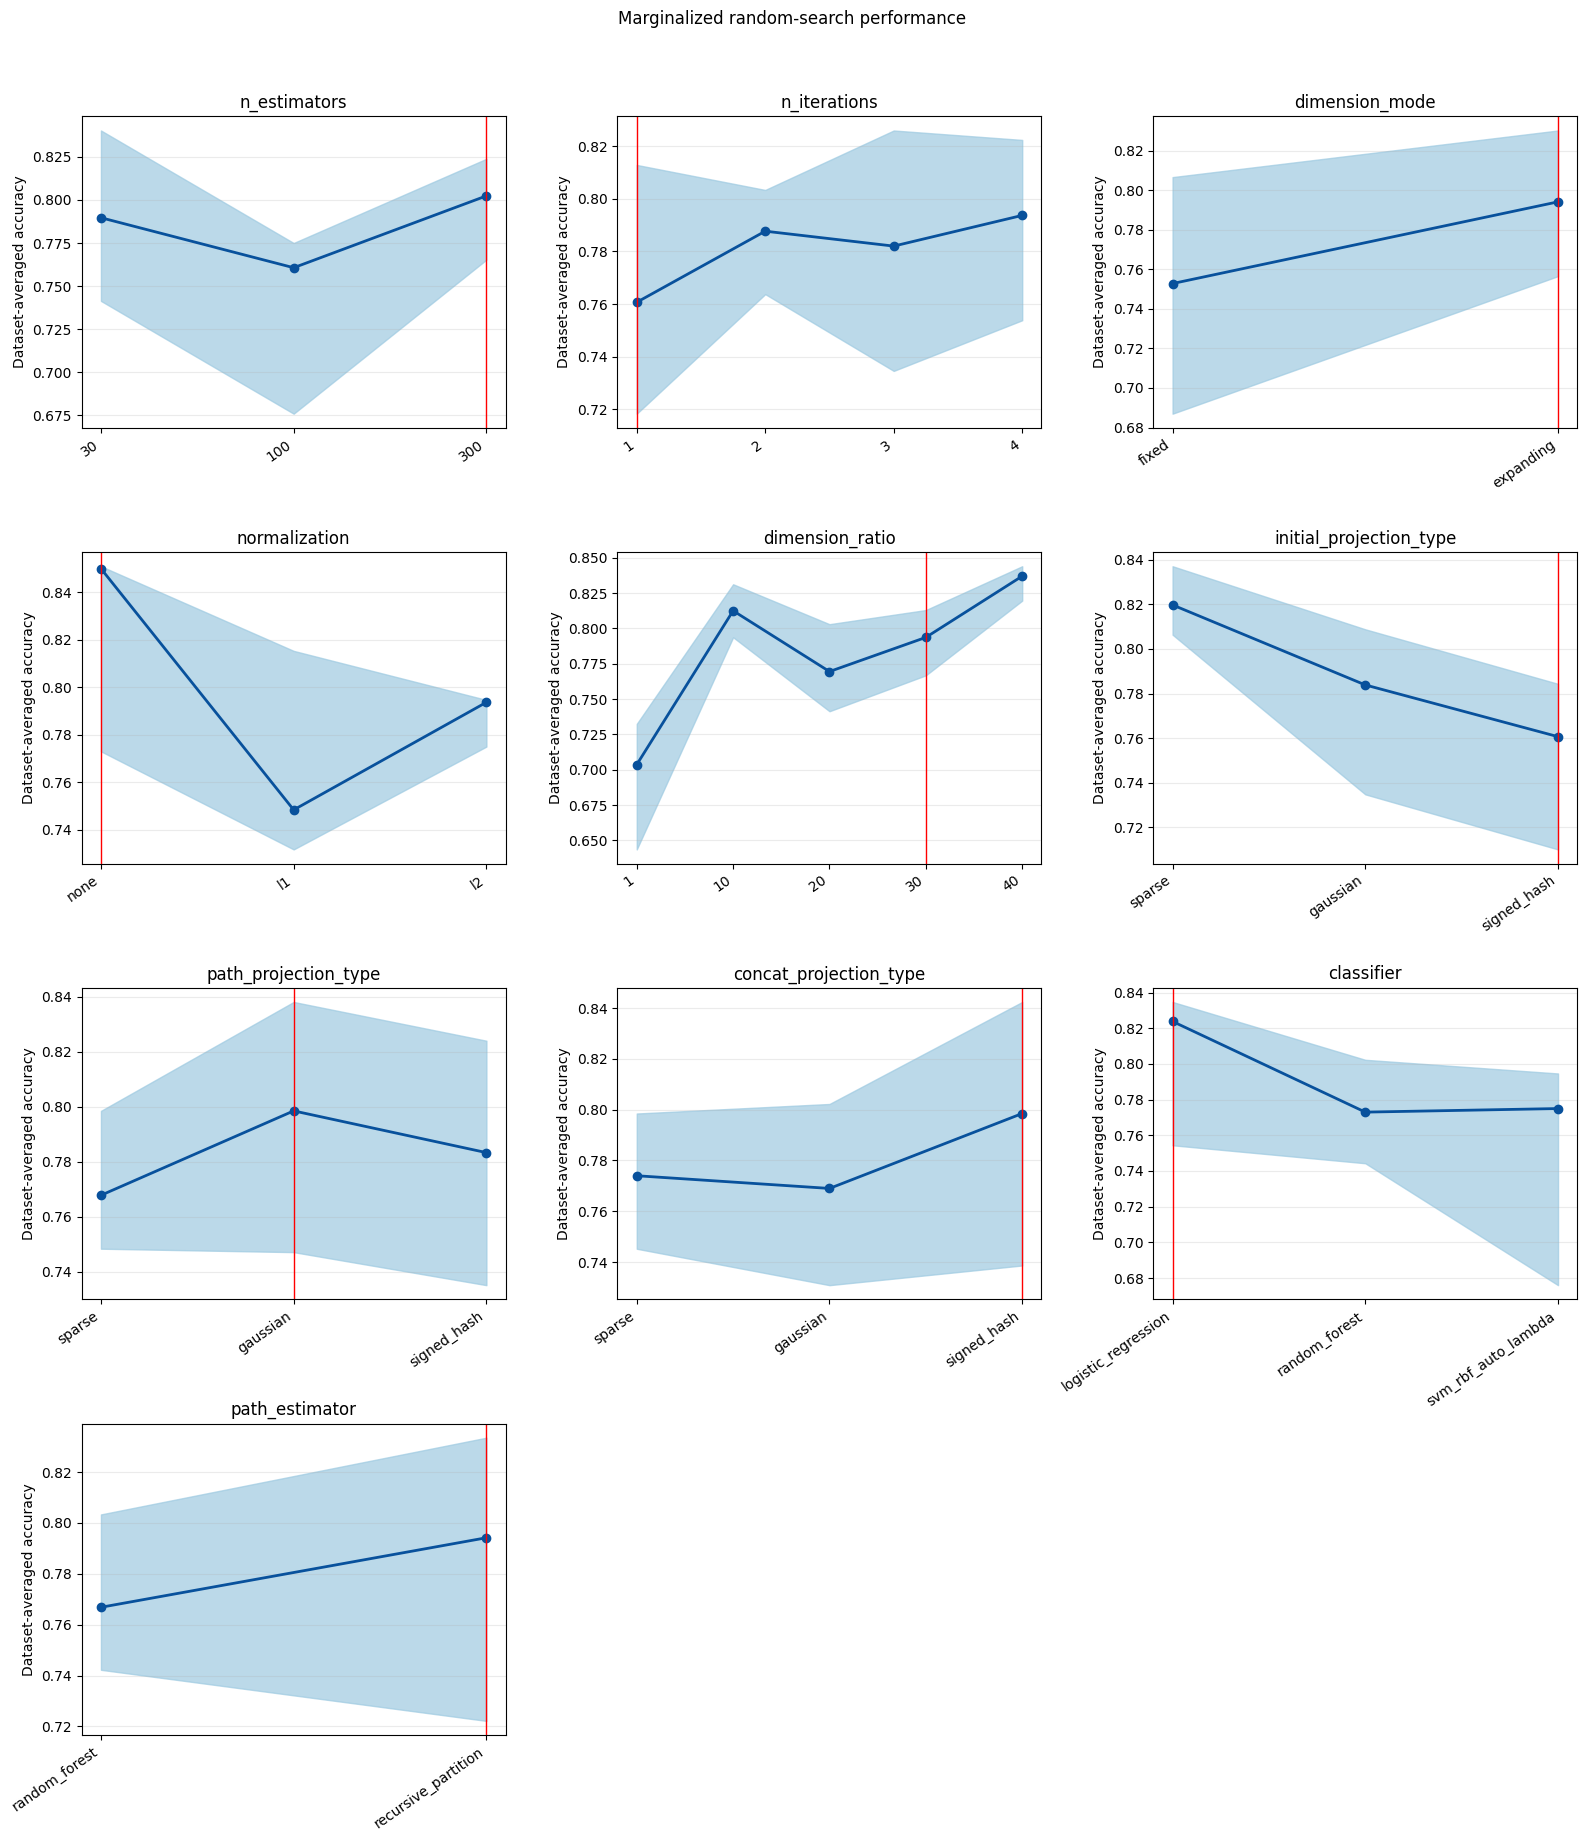

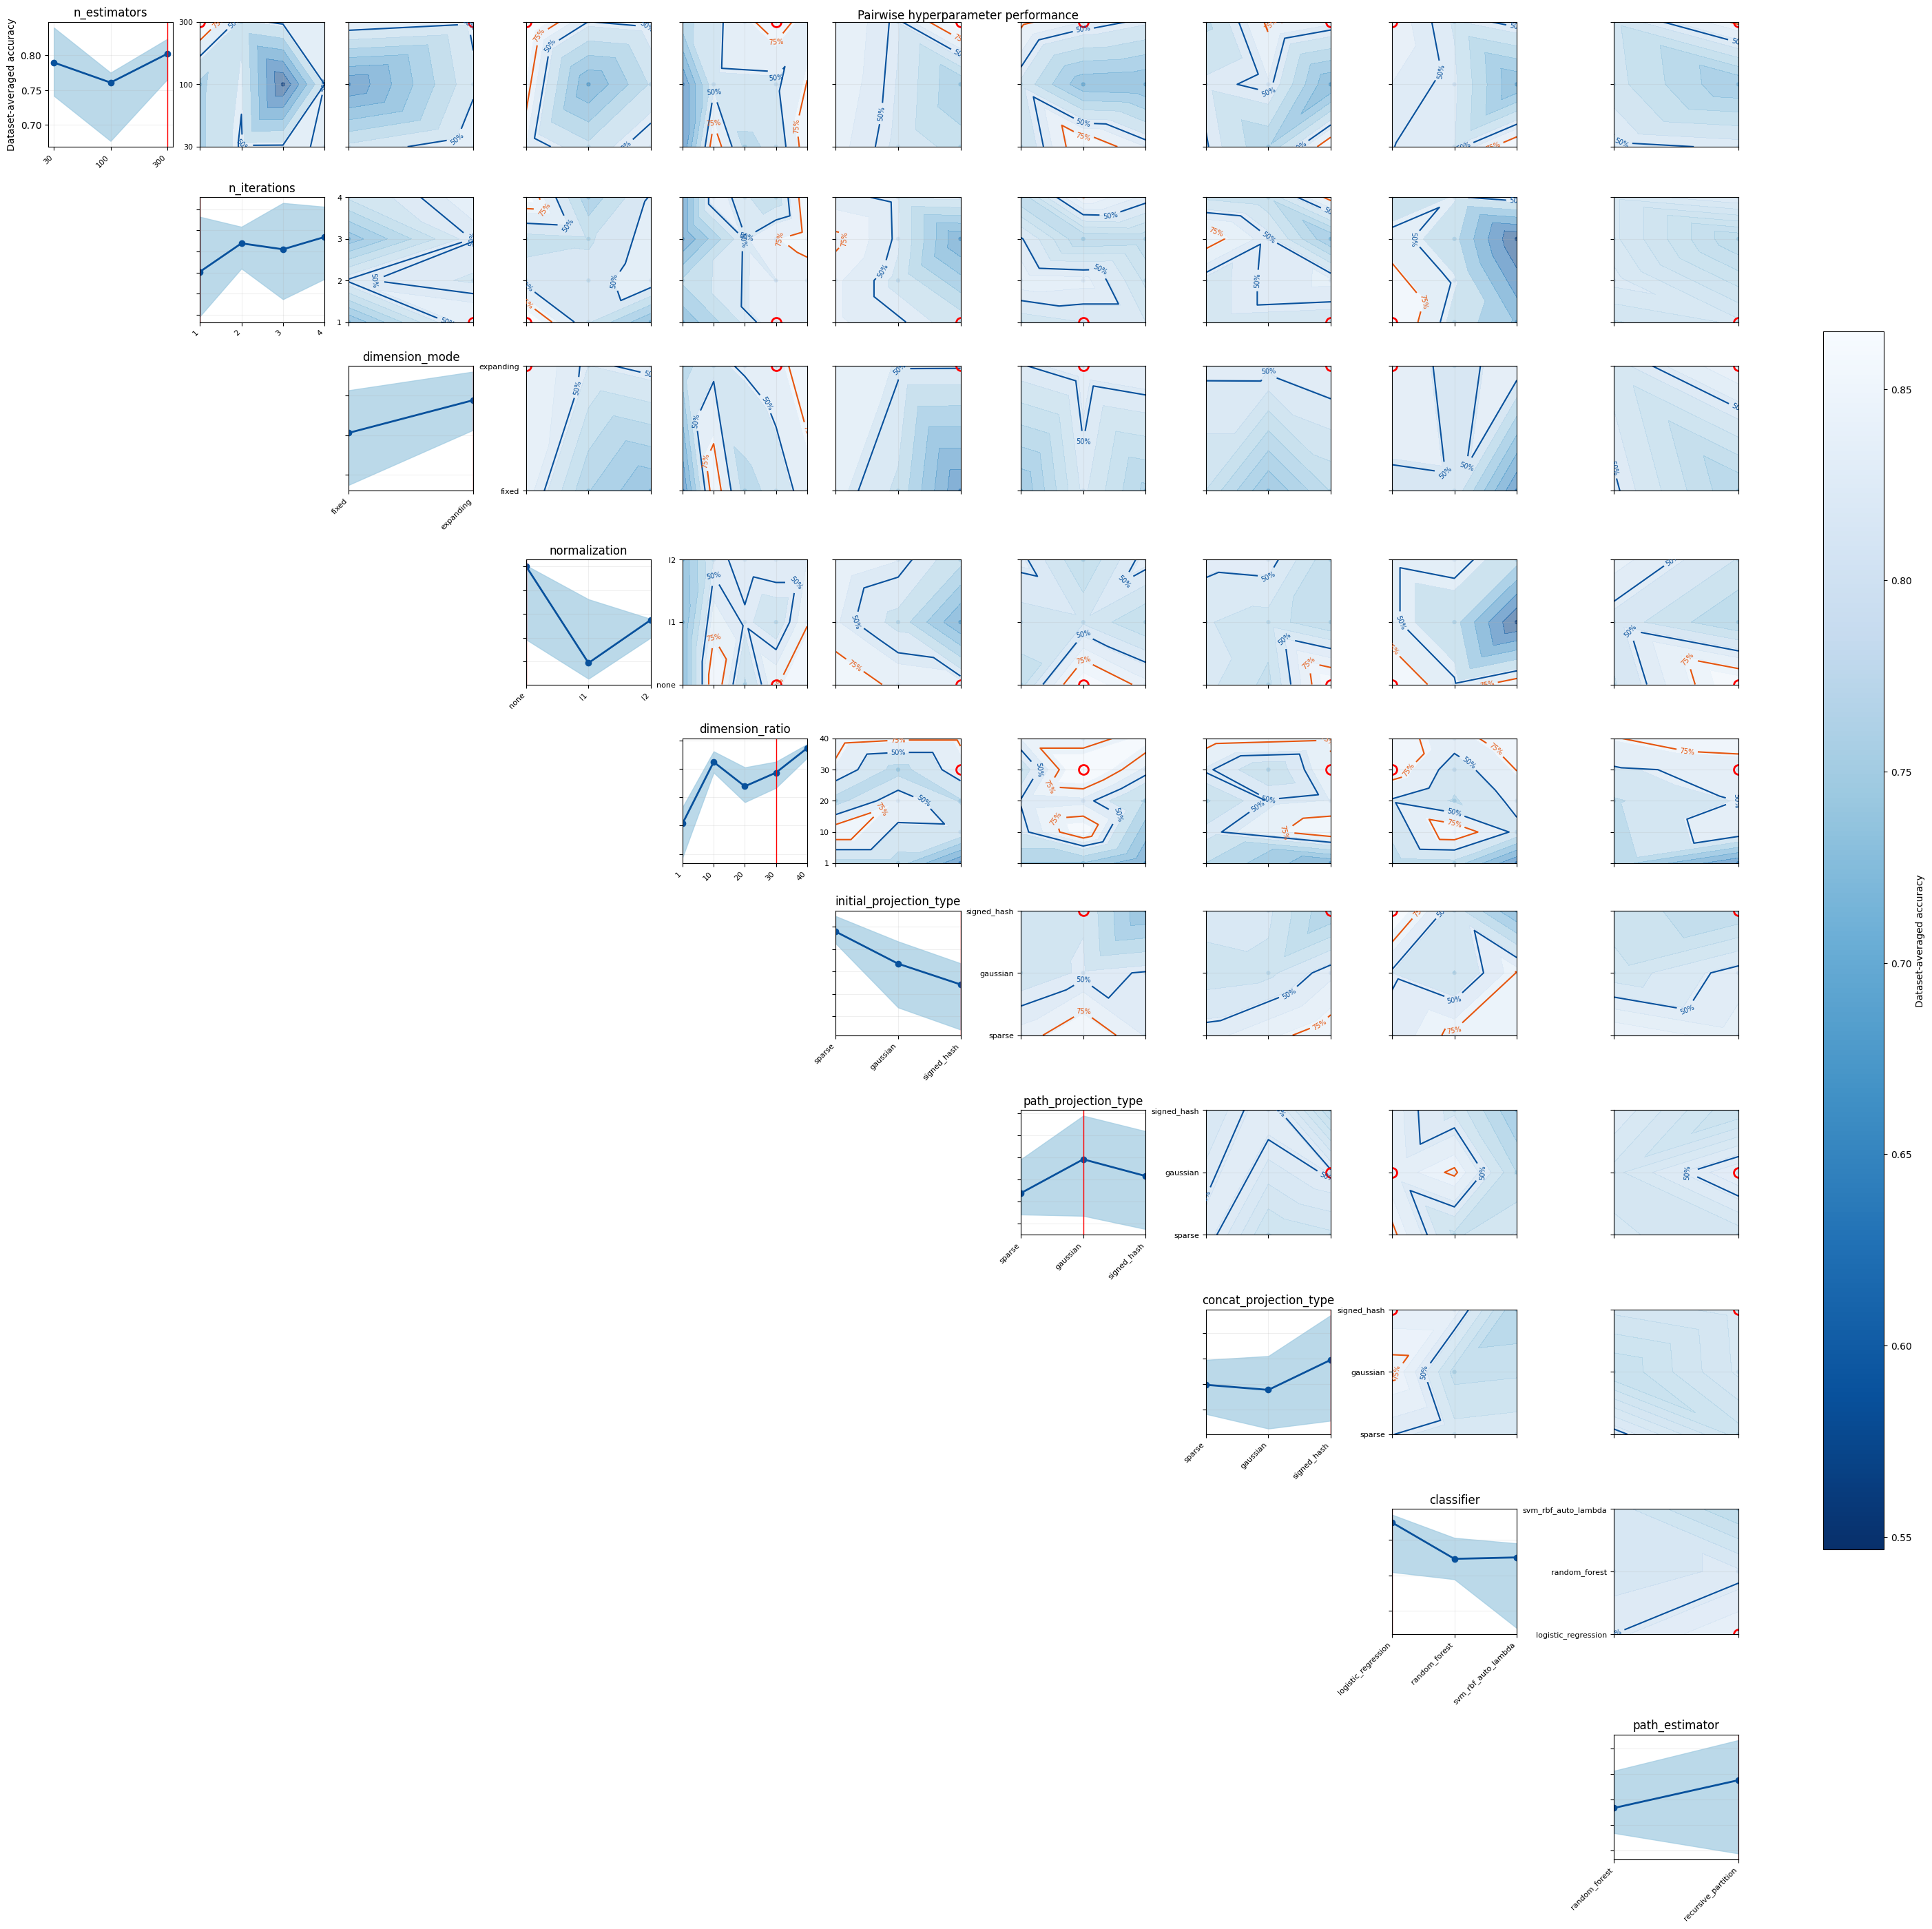

In [13]:
TOP_K = min(10, len(search_results))
top_results = search_results.head(TOP_K).copy()
display(top_results.style.format({
    'mean_accuracy': '{:.3f}',
    'std_dataset_accuracy': '{:.3f}',
    'mean_block_accuracy': '{:.3f}',
    'search_seconds': '{:.1f}',
}))

best_candidate_id, best_params = best_configuration(
    search_results,
    PARAMETER_RANGES,
)
display(pd.DataFrame([best_params]))
display(best_scores_by_dataset(block_results, best_candidate_id).style.format({
    'mean_accuracy': '{:.3f}',
    'std_accuracy': '{:.3f}',
}))

plot_top_candidates(search_results, top_k=TOP_K)
marginal_summary, marginal_figure = plot_marginalized_performance(
    search_results,
    PARAMETER_RANGES,
    best_params,
)
display(marginal_summary.style.format({
    'q25_accuracy': '{:.3f}',
    'median_accuracy': '{:.3f}',
    'q75_accuracy': '{:.3f}',
}))
plot_pairwise_performance(search_results, PARAMETER_RANGES, best_params);

The selected configuration maximizes the mean dataset-level accuracy on these evaluation blocks. For an unbiased final estimate, reserve additional datasets or repetitions as a validation set rather than reporting the same random-search score as final test performance.